In [1]:
pwd

'/gpfs/data/arsoyd01lab/machlm03/Segmentation/MedSAM2/oai_utils'

In [1]:
from PIL import Image
import numpy as np

# Load the grayscale mask image
mask_path = "/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/test/imgs/test_001_V00/masks/046.png"  # Update this with your actual file

mask_img = Image.open(mask_path).convert("L")
mask_array = np.array(mask_img)

# Extract unique grayscale values
unique_values = np.unique(mask_array)
print("Unique grayscale values in mask:", unique_values)


Unique grayscale values in mask: [  0  60 120 180 240]


In [2]:
import numpy as np
from PIL import Image, ImageOps
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import directed_hausdorff

# Explicit mapping from grayscale to class-ID
GRAY_TO_CLASS = {
    0: 0,    # background
    60: 1,   # class 1
    120: 2,  # class 2
    180: 3,  # class 3
    240: 4,  # class 4
}

# Define class colors for visualization
CLASS_COLORS = {
    0: (0, 0, 0),           # background - black
    1: (255, 0, 0),         # red
    2: (0, 255, 0),         # green
    3: (180, 0, 255),       # blue
    4: (255, 255, 0),       # yellow
}

# Legend mapping for class names and colors
CLASS_NAMES = {
    0: "Background",
    1: "Class 1 - Femoral Cartilage",
    2: "Class 2 - Tibial Cartilage",
    3: "Class 3 - Patellar Cartilage",
    4: "Class 4 - Meniscus",
}

def load_masks_from_npz(npz_path, key="gts"):
    data = np.load(npz_path)
    return data[key]  # shape: (D, H, W)

def hd95(gt_mask, pred_mask):
    gt_points = np.argwhere(gt_mask)
    pred_points = np.argwhere(pred_mask)
    if gt_points.size == 0 or pred_points.size == 0:  # Fixed: added ==
        return 0.0  # or np.nan if you want to skip empty masks
    forward_hd = directed_hausdorff(gt_points, pred_points)[0]
    backward_hd = directed_hausdorff(pred_points, gt_points)[0]
    return np.percentile([forward_hd, backward_hd], 95)

def remap_with_lookup(mask_img):
    arr = np.array(mask_img, dtype=np.int16)
    lut = np.zeros(256, dtype=np.uint8)
    for gray, cls in GRAY_TO_CLASS.items():
        lut[gray] = cls
    return lut[arr]

def mask_ids_to_rgb(mask_ids, class_colors):
    h, w = mask_ids.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask_ids == cls] = color
    return Image.fromarray(rgb)

def dice_iou(gt_bool, pred_bool):
    """Calculate Dice and IoU scores for boolean masks"""
    intersection = np.logical_and(gt_bool, pred_bool).sum()
    union = np.logical_or(gt_bool, pred_bool).sum()
    gt_sum = gt_bool.sum()
    pred_sum = pred_bool.sum()
    # Handle edge cases
    if gt_sum == 0 and pred_sum == 0:  # Fixed: added ==
        return 1.0, 1.0  # Perfect match when both are empty
    if union == 0:
        return 0.0, 0.0  # No union means no overlap
    dice = 2 * intersection / (gt_sum + pred_sum) if (gt_sum + pred_sum) > 0 else 0.0
    iou = intersection / union if union > 0 else 0.0
    return dice, iou

def list_images(directory):
    """List image files in directory"""
    extensions = ['.png', '.jpg', '.jpeg']
    files = []
    for ext in extensions:
        files.extend(directory.glob(f'*{ext}'))
        files.extend(directory.glob(f'*{ext.upper()}'))
    return [str(f) for f in files]

def overlay_image_mask(img_path, mask_path, class_colors, alpha=0.4):
    """Overlay a single mask (GT or prediction) on the original image."""
    img = Image.open(img_path).convert("RGB")
    img = ImageOps.exif_transpose(img)
    mask = Image.open(mask_path).convert("L")
    mask_rgb = mask_ids_to_rgb(remap_with_lookup(mask), class_colors)
    if mask_rgb.size != img.size:
        mask_rgb = mask_rgb.resize(img.size, Image.NEAREST)
    return Image.blend(img, mask_rgb, alpha=alpha)



def plot_segments(png,case,input_path,pre_masks_dir_oai,pre_masks_dir_medsam2):
    case=case

    labels = [1, 2, 3, 4]  # Fixed: only use classes that exist in GRAY_TO_CLASS
    # Define selection ratios
    sel_raw = [0.15,.20,.25,0.3, 0.35, 0.45, 0.50, 0.60,.75,.80,.90]
    # --- Match frames ---
    if png is False:
        # Load from npz
        # # Check if we're dealing with npz files or PNG files
        # gt_npz_path = Path(f"{input_path}/.npz")
        # pred_npz_path_oai = Path(f"{pre_masks_dir_oai}/.npz")
        # pred_npz_path_medsam = Path(f"{pre_masks_dir_medsam2}/.npz")
    
        gt_masks = load_masks_from_npz(input_path, key="gts")
        pred_masks_oai = load_masks_from_npz(pre_masks_dir_oai, key="pre")  # Added key parameter
        pred_masks_medsam = load_masks_from_npz(pre_masks_dir_medsam2, key="pre")  # Added key parameter
        
        num_frames = gt_masks.shape[0]
        selected_indices = [min(num_frames - 1, max(0, int(num_frames * r))) for r in sel_raw]
        selected_keys = selected_indices
        use_npz = True
    else:
        # Use PNG files
        mask_path = Path(f"{input_path}/masks")
        img_path = Path(f"{input_path}/imgs_png")
        pre_masks_dir_oai = Path(f"{pre_masks_dir_oai}/imgs")
        pre_masks_dir_medsam2 = Path(f"{pre_masks_dir_medsam2}/imgs")
    
        
        
        frame_files = list_images(mask_path)
        mask_files = list_images(pre_masks_dir_oai)
        sam_mask_files = list_images(pre_masks_dir_medsam2)
        
        frame_map = {Path(f).stem: f for f in frame_files}
        mask_map = {Path(f).stem: f for f in mask_files}
        sam_mask_map = {Path(f).stem: f for f in sam_mask_files}
        
        # Check for common files
        common = sorted(set(frame_map) & set(mask_map) & set(sam_mask_map))
        if not common:
            raise RuntimeError("No matching frame/mask filenames (by stem).")
        
        # Select frames
        num_frames = len(common)
        selected_indices = [min(num_frames - 1, max(0, int(num_frames * r))) for r in sel_raw]
        selected_keys = [common[i] for i in selected_indices]
        use_npz = False
    # --- Main loop ---
    dice_scores = []
    iou_scores = []
    hd_scores_oai = []
    hd_scores_msam = []
    
    plt.figure(figsize=(18, len(selected_keys) * 4))  # 3 columns
    
    for row_idx, k in enumerate(selected_keys):
        if use_npz:  # npz mode
            gt_ids = gt_masks[k]
            pred_ids = pred_masks_oai[k]
            sam_ids = pred_masks_medsam[k]
            img_file = None  # No base image in this case
            
            # Get present classes
            gt_labels_present = [l for l in labels if l in np.unique(gt_ids)]
            pred_labels_present = [l for l in labels if l in np.unique(pred_ids)]
            sam_labels_present = [l for l in labels if l in np.unique(sam_ids)]
            
        else:  # PNG mode
            img_file = img_path / f"{k}.png"
            gt_file = mask_path / frame_map[k]
            pred_file = pre_masks_dir_oai / mask_map[k]
            sam_pred_file = pre_masks_dir_medsam2 / sam_mask_map[k]
            
            # Load and process masks
            gt_mask_img = Image.open(gt_file).convert("L")
            pred_mask_img = Image.open(pred_file).convert("L")
            sam_mask_img = Image.open(sam_pred_file).convert("L")
            
            # Remap to class IDs
            gt_ids = remap_with_lookup(gt_mask_img)
            pred_ids = remap_with_lookup(pred_mask_img)
            sam_ids = remap_with_lookup(sam_mask_img)
            
            # Get present classes
            gt_labels_present = [l for l in labels if l in np.unique(gt_ids)]
            pred_labels_present = [l for l in labels if l in np.unique(pred_ids)]
            sam_labels_present = [l for l in labels if l in np.unique(sam_ids)]
        
        # Boolean masks for selected labels
        gt_bool = np.isin(gt_ids, labels)
        pred_bool = np.isin(pred_ids, labels)
        sam_bool = np.isin(sam_ids, labels)
        
        # Compute metrics
        d, j = dice_iou(gt_bool, pred_bool)
        d_sam, j_sam = dice_iou(gt_bool, sam_bool)
        hd = hd95(gt_bool, pred_bool)
        hd_sam = hd95(gt_bool, sam_bool)
        
        dice_scores.append(d)
        iou_scores.append(j)
        hd_scores_oai.append(hd)
        hd_scores_msam.append(hd_sam)
        
        # Create overlays
        if not use_npz and img_file and img_file.exists():
            base_img = Image.open(img_file).convert("RGB")
            base_img = ImageOps.exif_transpose(base_img)
            
            # Create RGB masks
            gt_rgb = mask_ids_to_rgb(gt_ids, CLASS_COLORS)
            pred_rgb = mask_ids_to_rgb(pred_ids, CLASS_COLORS)
            sam_rgb = mask_ids_to_rgb(sam_ids, CLASS_COLORS)
            
            # Resize if needed
            if gt_rgb.size != base_img.size:
                gt_rgb = gt_rgb.resize(base_img.size, Image.NEAREST)
            if pred_rgb.size != base_img.size:
                pred_rgb = pred_rgb.resize(base_img.size, Image.NEAREST)
            if sam_rgb.size != base_img.size:
                sam_rgb = sam_rgb.resize(base_img.size, Image.NEAREST)
            
            gt_overlay = Image.blend(base_img, gt_rgb, alpha=0.4)
            pred_overlay = Image.blend(base_img, pred_rgb, alpha=0.4)
            sam_overlay = Image.blend(base_img, sam_rgb, alpha=0.4)
        else:
            # Just show the masks without base image
            gt_overlay = mask_ids_to_rgb(gt_ids, CLASS_COLORS)
            pred_overlay = mask_ids_to_rgb(pred_ids, CLASS_COLORS)
            sam_overlay = mask_ids_to_rgb(sam_ids, CLASS_COLORS)
        
        # GT overlay
        plt.subplot(len(selected_keys), 3, row_idx * 3 + 1)
        plt.imshow(gt_overlay)
        if row_idx == 0:
            plt.title(f"Slice_{k} — GT\nClasses: {gt_labels_present}")
        else:
            plt.title(f"Slice_{k}")
        plt.axis("off")
        
        # OAI prediction overlay
        plt.subplot(len(selected_keys), 3, row_idx * 3 + 2)
        plt.imshow(pred_overlay)
        if row_idx == 0:
            plt.title(f"OAI_Prediction\nClasses: {pred_labels_present}\nDice={d:.3f}, IoU={j:.3f}, HD95={hd:.2f}")
        else:
            plt.title(f"\nDice={d:.3f}, IoU={j:.3f}, HD95={hd:.2f}")
        plt.axis("off")
        
        # MedSAM2 overlay  
        plt.subplot(len(selected_keys), 3, row_idx * 3 + 3)
        plt.imshow(sam_overlay)
        if row_idx == 0:
            plt.title(f"MedSAM2\nClasses: {sam_labels_present}\nDice={d_sam:.3f}, IoU={j_sam:.3f}, HD95={hd_sam:.2f}")
        else:
            plt.title(f"\nDice={d_sam:.3f}, IoU={j_sam:.3f}, HD95={hd_sam:.2f}")
        plt.axis("off")
    
    plt.tight_layout()
    
    # Add a legend for class colors
    patches = [mpatches.Patch(color=np.array(color)/255.0, label=f'{CLASS_NAMES[idx]}') 
               for idx, color in CLASS_COLORS.items()]
    plt.legend(handles=patches, loc='lower center', bbox_to_anchor=(-1, -0.25), ncol=4, fontsize=12)
    plt.savefig("./comparison_overlays_left.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print mean scores
    print(f"\n=== EVALUATION RESULTS ===")
    print(f"Evaluated classes: {labels}")
    print(f"Mean Dice over selected frames: {np.mean(dice_scores):.3f}")
    print(f"Mean IoU over selected frames:  {np.mean(iou_scores):.3f}")
    print(f"Mean HD95 OAI over selected frames: {np.mean(hd_scores_oai):.2f}")
    print(f"Mean HD95 MedSAM over selected frames: {np.mean(hd_scores_msam):.2f}")
    
    # Per-frame results
    print(f"\nPer-frame results:")
    for i, k in enumerate(selected_keys):
        print(f"Frame {k}: Dice={dice_scores[i]:.3f}, IoU={iou_scores[i]:.3f}, HD95_OAI={hd_scores_oai[i]:.2f}, HD95_Medsam={hd_scores_msam[i]:.2f}")





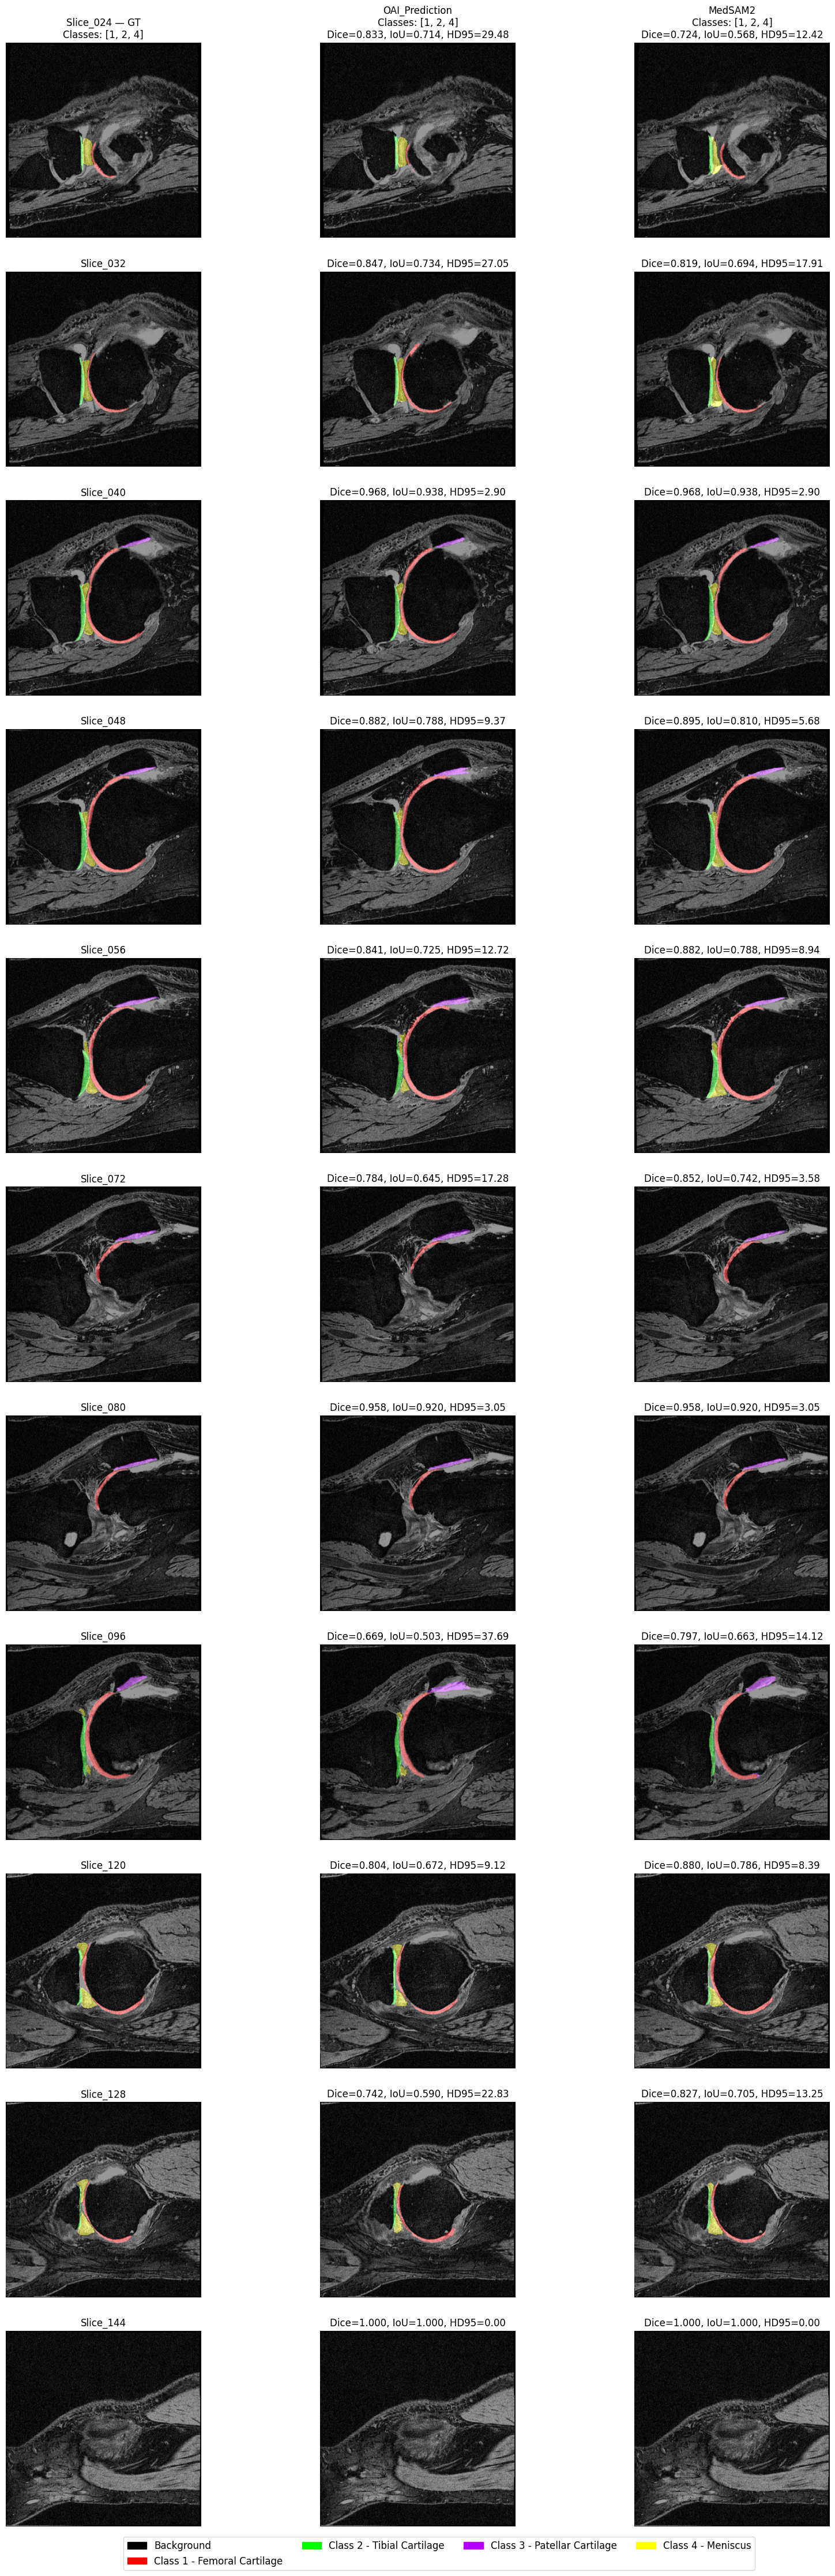


=== EVALUATION RESULTS ===
Evaluated classes: [1, 2, 3, 4]
Mean Dice over selected frames: 0.848
Mean IoU over selected frames:  0.748
Mean HD95 OAI over selected frames: 15.59
Mean HD95 MedSAM over selected frames: 8.20

Per-frame results:
Frame 024: Dice=0.833, IoU=0.714, HD95_OAI=29.48, HD95_Medsam=12.42
Frame 032: Dice=0.847, IoU=0.734, HD95_OAI=27.05, HD95_Medsam=17.91
Frame 040: Dice=0.968, IoU=0.938, HD95_OAI=2.90, HD95_Medsam=2.90
Frame 048: Dice=0.882, IoU=0.788, HD95_OAI=9.37, HD95_Medsam=5.68
Frame 056: Dice=0.841, IoU=0.725, HD95_OAI=12.72, HD95_Medsam=8.94
Frame 072: Dice=0.784, IoU=0.645, HD95_OAI=17.28, HD95_Medsam=3.58
Frame 080: Dice=0.958, IoU=0.920, HD95_OAI=3.05, HD95_Medsam=3.05
Frame 096: Dice=0.669, IoU=0.503, HD95_OAI=37.69, HD95_Medsam=14.12
Frame 120: Dice=0.804, IoU=0.672, HD95_OAI=9.12, HD95_Medsam=8.39
Frame 128: Dice=0.742, IoU=0.590, HD95_OAI=22.83, HD95_Medsam=13.25
Frame 144: Dice=1.000, IoU=1.000, HD95_OAI=0.00, HD95_Medsam=0.00


In [3]:

# case="test_002_V00"
# plot_segments(
# case =case,

# input_path=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/test/imgs/{case}",
# pre_masks_dir_oai=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/mask_oai_inference/{case}",
# pre_masks_dir_medsam2=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/mask_medsam_inference/{case}",
# png = True
# )
case="test_002_V00"
plot_segments(
case =case,
input_path=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/test/npz/{case}.npz",
pre_masks_dir_oai=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/bbx_inference/OAI_inference_bbx/{case}.npz",
pre_masks_dir_medsam2=f"/gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/bbx_inference/MedSam2_inference_bbx/{case}.npz",
png = False
)
# /gpfs/home/machlm03/Segmentation/IWOAI_Segmentation_Challenge/bbx_inference/MedSam2_inference_bbx/test_001_V01.npz
# Evaluate all classes present in your data